# 03 — Subject-level comparison of matched PCA and ICA components

This notebook is the **next-step analysis notebook** after the PCA-vs-ICA component comparison.

## Main question
Even when the spatial maps from PCA and ICA are **not exactly the same**, are the matched components still carrying a **similar subject-level signal**?

## What this notebook does
1. Loads PCA and ICA component maps, labels, and per-subject timecourses  
2. Matches PCA and ICA components using **absolute spatial correlation** (or loads the saved matching table from the previous notebook)  
3. Computes **subject-level summaries** for each matched component in **L1**, **Ln**, and **Delta = Ln − L1**  
4. Compares matched PCA and ICA components across subjects using:
   - summary-feature correlations
   - subject-profile similarity
   - group separation effect sizes
   - single-pair cross-method prediction agreement
5. Saves clean CSV tables and figures for interpretation

## Scientific interpretation
This notebook helps answer whether:
- PCA and ICA are encoding the **same individual differences** in different spatial forms, or
- PCA and ICA are capturing **different subject-level signals**

## Notes before running
- Update the path cell below.
- This notebook expects per-subject timecourse files in `timecourses/`.
- Typical file name patterns expected:
  - PCA: `sub-01_task-compL1_PCsK20.csv` or `.npy`
  - ICA: `sub-01_task-compL1_ICsK20.csv` or `.npy`
- If your filenames differ slightly, update the filename patterns in the helper functions.

In [7]:

from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, zscore
from scipy.spatial.distance import cosine

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [8]:

# -----------------------------
# Edit these paths
# -----------------------------
ROOT_PCA = Path("/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2")
ROOT_ICA = Path("/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA")

OUTDIR = Path("./results_subject_level_pca_ica")
OUTDIR.mkdir(parents=True, exist_ok=True)

K = 20
RANDOM_STATE = 42
THRESHOLD_Z = 2.0   # used only if we need to recompute matching diagnostics
TOP_N_MATCHES_TO_PLOT = 8

# Optional:
# If you already ran Notebook 02 and saved a matching CSV, set the path here.
PRECOMPUTED_MATCH_CSV = None
# Example:
# PRECOMPUTED_MATCH_CSV = Path("./results_pca_ica_comparison/matched_components_by_abs_r.csv")

# Optional: if you know TR, low-frequency features can be added later
TR_SECONDS = None

In [9]:

@dataclass
class MethodConfig:
    name: str
    prefix: str
    comp_keyword: str
    components_img: Path
    timecourse_dir: Path
    static_features_csv: Path
    labels_csv: Path

pca_cfg = MethodConfig(
    name="PCA",
    prefix="PC",
    comp_keyword="PCs",
    components_img=ROOT_PCA / f"group_pca_K{K}_components.nii.gz",
    timecourse_dir=ROOT_PCA / "timecourses",
    static_features_csv=ROOT_PCA / f"features_static_nonZ_K{K}.csv",
    labels_csv=ROOT_PCA / "proficiency_labels.csv",
)

ica_cfg = MethodConfig(
    name="ICA",
    prefix="IC",
    comp_keyword="ICs",
    components_img=ROOT_ICA / f"group_ica_K{K}_components.nii.gz",
    timecourse_dir=ROOT_ICA / "timecourses",
    static_features_csv=ROOT_ICA / f"features_static_nonZ_K{K}.csv",
    labels_csv=ROOT_ICA / "proficiency_labels.csv",
)

for cfg in [pca_cfg, ica_cfg]:
    print(cfg)

MethodConfig(name='PCA', prefix='PC', comp_keyword='PCs', components_img=PosixPath('/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/group_pca_K20_components.nii.gz'), timecourse_dir=PosixPath('/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/timecourses'), static_features_csv=PosixPath('/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/features_static_nonZ_K20.csv'), labels_csv=PosixPath('/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2/proficiency_labels.csv'))
MethodConfig(name='ICA', prefix='IC', comp_keyword='ICs', components_img=PosixPath('/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/group_ica_K20_components.nii.gz'), timecourse_dir=PosixPath('/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/timecourses'), static_features_csv=PosixPath('/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/features_static_nonZ_K20.csv'), labels_csv=PosixPath('/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/

## Utility functions
These helpers are written to be reusable and easier to debug than a long notebook full of repeated code blocks.

In [10]:

def fixed_pipeline(C: float = 1.0, penalty: str = "l2") -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",
            C=C,
            penalty=penalty,
            max_iter=5000,
            random_state=RANDOM_STATE,
        ))
    ])

def infer_subject_column(df: pd.DataFrame) -> str:
    for c in ["subject", "sub", "participant_id", "participant", "Subject"]:
        if c in df.columns:
            return c
    raise ValueError("Could not infer subject column.")

def infer_label_column(df: pd.DataFrame) -> str:
    for c in ["y", "label", "group", "target", "class"]:
        if c in df.columns:
            return c
    raise ValueError("Could not infer label column.")

def standardize_subject_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r"(sub[-_]?\d+)", s, flags=re.I)
    if m:
        s = m.group(1)
    s = s.replace("_", "-")
    if re.fullmatch(r"sub-\d+", s, flags=re.I):
        return s.lower()
    m2 = re.search(r"(\d+)", s)
    if m2:
        return f"sub-{int(m2.group(1)):02d}"
    return s.lower()

def load_labels(labels_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(labels_csv)
    subj_col = infer_subject_column(df)
    y_col = infer_label_column(df)
    out = df[[subj_col, y_col]].copy()
    out.columns = ["subject", "y"]
    out["subject"] = out["subject"].map(standardize_subject_id)
    out = out.drop_duplicates("subject").sort_values("subject").reset_index(drop=True)
    return out

def extract_component_id(col: str, prefix: str) -> Optional[str]:
    m = re.search(rf"({prefix}\d+)", str(col))
    return m.group(1) if m else None

def component_number(comp_id: str) -> int:
    m = re.search(r"(\d+)$", comp_id)
    if not m:
        raise ValueError(f"Could not parse component number from {comp_id}")
    return int(m.group(1))

def safe_logstd(x: np.ndarray) -> float:
    return float(np.log(np.std(x, ddof=1) + 1e-8))

def lag1_autocorr(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) < 3 or np.std(x) < 1e-12:
        return np.nan
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])

def summarize_timecourse(x: np.ndarray) -> Dict[str, float]:
    x = np.asarray(x, dtype=float).ravel()
    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x, ddof=1)),
        "logstd": safe_logstd(x),
        "ac1": lag1_autocorr(x),
    }

def flatten_component_maps(img_path: Path) -> np.ndarray:
    img = nib.load(str(img_path))
    data = img.get_fdata()
    if data.ndim != 4:
        raise ValueError(f"Expected 4D component image, got shape {data.shape}")
    return data.reshape(-1, data.shape[-1])

def corr_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    # columns = components
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    A = A - A.mean(axis=0, keepdims=True)
    B = B - B.mean(axis=0, keepdims=True)
    A /= (A.std(axis=0, keepdims=True) + 1e-12)
    B /= (B.std(axis=0, keepdims=True) + 1e-12)
    return (A.T @ B) / (A.shape[0] - 1)

def greedy_match(score_mat: np.ndarray) -> List[Tuple[int, int, float]]:
    score = score_mat.copy()
    pairs = []
    used_rows, used_cols = set(), set()
    n_rows, n_cols = score.shape
    while len(used_rows) < n_rows and len(used_cols) < n_cols:
        best = None
        best_val = -np.inf
        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if score[i, j] > best_val:
                    best_val = score[i, j]
                    best = (i, j)
        if best is None:
            break
        i, j = best
        pairs.append((i, j, float(score[i, j])))
        used_rows.add(i)
        used_cols.add(j)
    return pairs

def hungarian_match(score_mat: np.ndarray) -> List[Tuple[int, int, float]]:
    row_ind, col_ind = linear_sum_assignment(-score_mat)
    pairs = [(int(i), int(j), float(score_mat[i, j])) for i, j in zip(row_ind, col_ind)]
    pairs = sorted(pairs, key=lambda x: x[0])
    return pairs

def thresholded_dice(a: np.ndarray, b: np.ndarray, zthr: float = 2.0) -> float:
    za = np.abs(zscore(a, nan_policy="omit"))
    zb = np.abs(zscore(b, nan_policy="omit"))
    ma = za >= zthr
    mb = zb >= zthr
    denom = ma.sum() + mb.sum()
    if denom == 0:
        return np.nan
    return float(2 * np.logical_and(ma, mb).sum() / denom)

def plot_heatmap(mat: np.ndarray, row_labels: List[str], col_labels: List[str], title: str, out_png: Optional[Path] = None):
    fig = plt.figure(figsize=(10, 8))
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(col_labels)), col_labels, rotation=90)
    plt.yticks(range(len(row_labels)), row_labels)
    plt.title(title)
    plt.tight_layout()
    if out_png is not None:
        plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()

def display_top(df: pd.DataFrame, n: int = 10):
    display(df.head(n))

## Step 1 — Load labels and verify overlap

In [11]:

labels_pca = load_labels(pca_cfg.labels_csv)
labels_ica = load_labels(ica_cfg.labels_csv)

common_subjects = sorted(set(labels_pca["subject"]) & set(labels_ica["subject"]))
labels = labels_pca[labels_pca["subject"].isin(common_subjects)].copy().sort_values("subject")
labels = labels.merge(labels_ica.rename(columns={"y": "y_ica"}), on="subject", how="left")
assert (labels["y"] == labels["y_ica"]).all(), "PCA and ICA labels do not match for overlapping subjects."
labels = labels[["subject", "y"]].reset_index(drop=True)

print("Common subjects:", len(common_subjects))
print(labels["y"].value_counts().sort_index())
display(labels.head())

Common subjects: 26
advanced        15
intermediate    11
Name: y, dtype: int64


,subject,y
0,sub-01,advanced
1,sub-02,advanced
2,sub-03,advanced
3,sub-04,advanced
4,sub-05,advanced


## Step 2 — Match PCA and ICA components
This uses the same idea as Notebook 02.

Preferred strategy:
- If a previous matching CSV exists, load it.
- Otherwise, recompute matching from **absolute spatial correlation**.

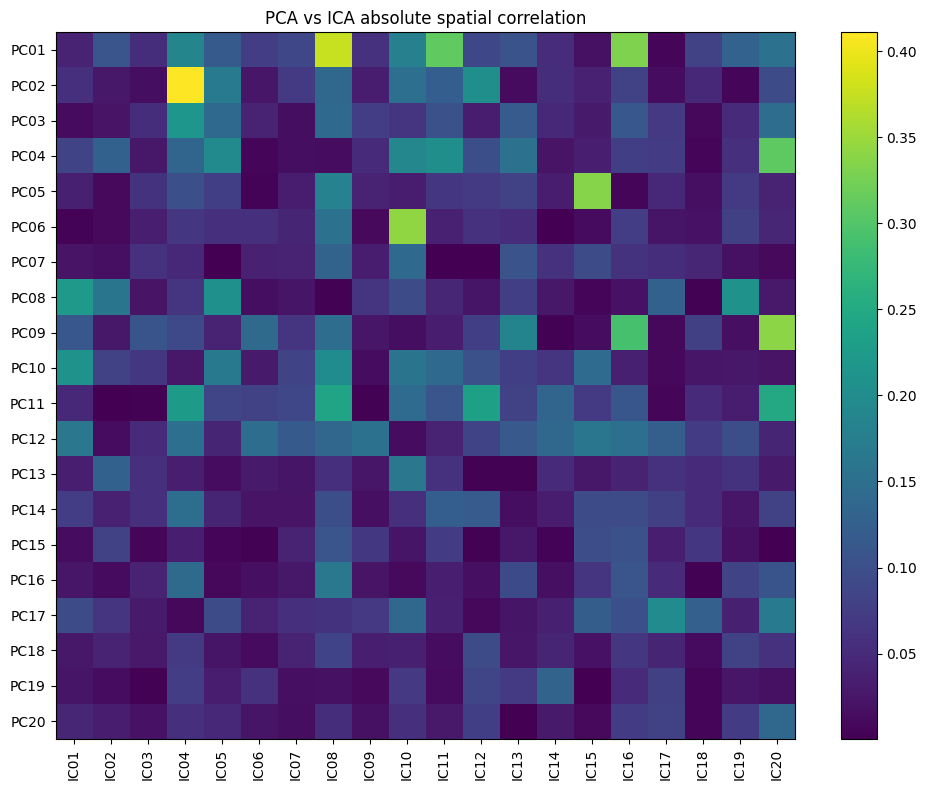

,pca_component,ica_component,abs_spatial_r,signed_spatial_r,dice_zthr2
0,PC02,IC04,0.410960,0.410960,0.377738
1,PC01,IC08,0.376451,0.376451,0.338955
2,PC06,IC10,0.342757,0.342757,0.317186
3,PC05,IC15,0.336843,0.336843,0.208949
4,PC04,IC20,0.309092,0.309092,0.200675
5,PC09,IC16,0.291118,0.291118,0.179489
6,PC11,IC12,0.233876,-0.233876,0.068442
7,PC10,IC01,0.212131,-0.212131,0.159784
8,PC08,IC19,0.209667,-0.209667,0.129194
9,PC17,IC17,0.198758,0.198758,0.143221


In [12]:

def build_component_ids(prefix: str, K: int) -> List[str]:
    return [f"{prefix}{i:02d}" for i in range(1, K + 1)]

pca_ids = build_component_ids("PC", K)
ica_ids = build_component_ids("IC", K)

if PRECOMPUTED_MATCH_CSV is not None and Path(PRECOMPUTED_MATCH_CSV).exists():
    matches_df = pd.read_csv(PRECOMPUTED_MATCH_CSV)
    print("Loaded precomputed match table from:", PRECOMPUTED_MATCH_CSV)
else:
    pca_maps = flatten_component_maps(pca_cfg.components_img)
    ica_maps = flatten_component_maps(ica_cfg.components_img)

    signed_r = corr_matrix(pca_maps, ica_maps)
    abs_r = np.abs(signed_r)

    dice_mat = np.zeros_like(abs_r)
    for i in range(abs_r.shape[0]):
        for j in range(abs_r.shape[1]):
            dice_mat[i, j] = thresholded_dice(pca_maps[:, i], ica_maps[:, j], zthr=THRESHOLD_Z)

    pairs = hungarian_match(abs_r)
    rows = []
    for i, j, score in pairs:
        rows.append({
            "pca_component": pca_ids[i],
            "ica_component": ica_ids[j],
            "abs_spatial_r": float(abs_r[i, j]),
            "signed_spatial_r": float(signed_r[i, j]),
            "dice_zthr2": float(dice_mat[i, j]),
        })
    matches_df = pd.DataFrame(rows).sort_values("abs_spatial_r", ascending=False).reset_index(drop=True)
    matches_df.to_csv(OUTDIR / "matched_components_by_abs_r.csv", index=False)

    pd.DataFrame(abs_r, index=pca_ids, columns=ica_ids).to_csv(OUTDIR / "spatial_abs_r_matrix.csv")
    pd.DataFrame(signed_r, index=pca_ids, columns=ica_ids).to_csv(OUTDIR / "spatial_signed_r_matrix.csv")
    pd.DataFrame(dice_mat, index=pca_ids, columns=ica_ids).to_csv(OUTDIR / "spatial_dice_matrix.csv")

    plot_heatmap(abs_r, pca_ids, ica_ids, "PCA vs ICA absolute spatial correlation", OUTDIR / "heatmap_abs_spatial_r.png")

display_top(matches_df, 12)

## Step 3 — Load per-subject timecourses
This notebook supports `.csv` and `.npy` files.

Each loaded timecourse becomes a matrix:
- rows = time points
- columns = components

In [13]:

def candidate_patterns(cfg: MethodConfig, subject: str, task: str, K: int) -> List[str]:
    # Tries common filename variants
    subj_variants = [subject, subject.replace("-", "_")]
    task_variants = [task, task.replace("-", "_")]
    stem_patterns = []
    for sv in subj_variants:
        for tv in task_variants:
            stem_patterns.extend([
                f"{sv}_task-{tv}_{cfg.comp_keyword}K{K}.csv",
                f"{sv}_task-{tv}_{cfg.comp_keyword}K{K}.npy",
                f"{sv}_task-{tv}_allruns_{cfg.comp_keyword}K{K}.csv",
                f"{sv}_task-{tv}_allruns_{cfg.comp_keyword}K{K}.npy",
                f"{sv}_{tv}_{cfg.comp_keyword}K{K}.csv",
                f"{sv}_{tv}_{cfg.comp_keyword}K{K}.npy",
            ])
    return stem_patterns

def find_timecourse_file(cfg: MethodConfig, subject: str, task: str, K: int) -> Path:
    candidates = []
    for pat in candidate_patterns(cfg, subject, task, K):
        candidates.extend(list(cfg.timecourse_dir.glob(pat)))
    # fallback broader search
    if not candidates:
        subj_num = re.search(r"(\d+)$", subject).group(1)
        broad = list(cfg.timecourse_dir.glob(f"*{subj_num}*{task}*{cfg.comp_keyword}K{K}*"))
        candidates.extend(broad)
    candidates = [p for p in candidates if p.suffix.lower() in [".csv", ".npy"]]
    if not candidates:
        raise FileNotFoundError(f"No timecourse file found for {cfg.name} | {subject} | {task}")
    candidates = sorted(set(candidates))
    return candidates[0]

def load_timecourse_matrix(path: Path) -> np.ndarray:
    if path.suffix.lower() == ".npy":
        X = np.load(path)
    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        # Keep only numeric columns; handle a leading unnamed index column
        numeric = df.select_dtypes(include=[np.number])
        X = numeric.to_numpy()
    else:
        raise ValueError(f"Unsupported file type: {path}")
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"Expected 2D matrix in {path}, got shape {X.shape}")
    return X

def load_subject_task_timecourse(cfg: MethodConfig, subject: str, task: str, K: int) -> np.ndarray:
    f = find_timecourse_file(cfg, subject, task, K)
    X = load_timecourse_matrix(f)
    if X.shape[1] != K and X.shape[0] == K:
        # common orientation issue: transpose if needed
        X = X.T
    if X.shape[1] != K:
        raise ValueError(f"Expected {K} components in {f}, got shape {X.shape}")
    return X

# quick existence check on first few subjects
for cfg in [pca_cfg, ica_cfg]:
    print("\nChecking", cfg.name)
    for subj in labels["subject"].head(3):
        for task in ["compL1", "compLn"]:
            try:
                p = find_timecourse_file(cfg, subj, task, K)
                print("  OK:", subj, task, "->", p.name)
            except Exception as e:
                print("  Missing:", subj, task, "|", e)


Checking PCA
  OK: sub-01 compL1 -> sub-01_task-compL1_PCsK20.csv
  OK: sub-01 compLn -> sub-01_task-compLn_PCsK20.csv
  OK: sub-02 compL1 -> sub-02_task-compL1_PCsK20.csv
  OK: sub-02 compLn -> sub-02_task-compLn_PCsK20.csv
  OK: sub-03 compL1 -> sub-03_task-compL1_PCsK20.csv
  OK: sub-03 compLn -> sub-03_task-compLn_PCsK20.csv

Checking ICA
  OK: sub-01 compL1 -> sub-01_task-compL1_ICsK20.csv
  OK: sub-01 compLn -> sub-01_task-compLn_ICsK20.csv
  OK: sub-02 compL1 -> sub-02_task-compL1_ICsK20.csv
  OK: sub-02 compLn -> sub-02_task-compLn_ICsK20.csv
  OK: sub-03 compL1 -> sub-03_task-compL1_ICsK20.csv
  OK: sub-03 compLn -> sub-03_task-compLn_ICsK20.csv


## Step 4 — Build a subject-level matched-component summary table

For every matched pair:
- load PCA and ICA timecourses for the same subject
- extract the matched component column
- summarize separately for `compL1` and `compLn`
- compute `Delta = Ln − L1` for each summary feature

This creates one long-format table that becomes the base for the rest of the analysis.

In [14]:
def normalize_label(value):
    """
    Convert label to binary:
    advanced -> 1
    intermediate -> 0

    Also handles already-numeric values.
    """
    if pd.isna(value):
        raise ValueError("Missing label value.")

    if isinstance(value, (int, np.integer)):
        return int(value)

    if isinstance(value, (float, np.floating)):
        return int(value)

    s = str(value).strip().lower()

    if s in ["advanced", "adv", "1", "true", "yes"]:
        return 1
    elif s in ["intermediate", "int", "0", "false", "no"]:
        return 0
    else:
        raise ValueError(f"Unrecognized label value: {value}")


def get_binary_label(lrow):
    """
    Read label from possible columns and convert to binary.
    """
    for col in ["y", "group", "label"]:
        if col in lrow.index:
            return normalize_label(lrow[col])
    raise KeyError("No label column found. Expected one of: y, group, label")


def build_subject_component_table(
    labels_df: pd.DataFrame,
    matches_df: pd.DataFrame,
    pca_cfg: MethodConfig,
    ica_cfg: MethodConfig,
    K: int,
) -> pd.DataFrame:
    rows = []

    for _, mrow in matches_df.iterrows():
        pca_comp = mrow["pca_component"]
        ica_comp = mrow["ica_component"]

        pca_idx = component_number(pca_comp) - 1
        ica_idx = component_number(ica_comp) - 1

        for _, lrow in labels_df.iterrows():
            subject = lrow["subject"]
            y = get_binary_label(lrow)

            try:
                pca_l1 = load_subject_task_timecourse(pca_cfg, subject, "compL1", K)[:, pca_idx]
                pca_ln = load_subject_task_timecourse(pca_cfg, subject, "compLn", K)[:, pca_idx]
                ica_l1 = load_subject_task_timecourse(ica_cfg, subject, "compL1", K)[:, ica_idx]
                ica_ln = load_subject_task_timecourse(ica_cfg, subject, "compLn", K)[:, ica_idx]
            except FileNotFoundError as e:
                print("Skipping missing subject/task:", e)
                continue

            pca_l1_s = summarize_timecourse(pca_l1)
            pca_ln_s = summarize_timecourse(pca_ln)
            ica_l1_s = summarize_timecourse(ica_l1)
            ica_ln_s = summarize_timecourse(ica_ln)

            row = {
                "subject": subject,
                "y": y,
                "group_label": lrow["y"] if "y" in lrow.index else np.nan,
                "pca_component": pca_comp,
                "ica_component": ica_comp,
                "abs_spatial_r": mrow.get("abs_spatial_r", np.nan),
                "signed_spatial_r": mrow.get("signed_spatial_r", np.nan),
                "dice_zthr2": mrow.get("dice_zthr2", np.nan),
            }

            for stat in ["mean", "std", "logstd", "ac1"]:
                row[f"PCA_L1_{stat}"] = pca_l1_s[stat]
                row[f"PCA_Ln_{stat}"] = pca_ln_s[stat]
                row[f"PCA_DELTA_{stat}"] = pca_ln_s[stat] - pca_l1_s[stat]

                row[f"ICA_L1_{stat}"] = ica_l1_s[stat]
                row[f"ICA_Ln_{stat}"] = ica_ln_s[stat]
                row[f"ICA_DELTA_{stat}"] = ica_ln_s[stat] - ica_l1_s[stat]

            rows.append(row)

    out = pd.DataFrame(rows)
    return out.sort_values(["pca_component", "subject"]).reset_index(drop=True)


# Optional: check labels before running
print(labels.head())
if "y" in labels.columns:
    print("Unique y values:", labels["y"].unique())

# Build and save subject-level table
subject_tbl = build_subject_component_table(labels, matches_df, pca_cfg, ica_cfg, K)
subject_tbl.to_csv(OUTDIR / "subject_level_matched_component_table.csv", index=False)

print("Rows:", len(subject_tbl))
print("Unique matched pairs:", subject_tbl[["pca_component", "ica_component"]].drop_duplicates().shape[0])
display(subject_tbl.head())

  subject         y
0  sub-01  advanced
1  sub-02  advanced
2  sub-03  advanced
3  sub-04  advanced
4  sub-05  advanced
Unique y values: ['advanced' 'intermediate']
Rows: 520
Unique matched pairs: 20


,subject,y,group_label,pca_component,ica_component,abs_spatial_r,signed_spatial_r,dice_zthr2,PCA_L1_mean,PCA_Ln_mean,PCA_DELTA_mean,ICA_L1_mean,ICA_Ln_mean,ICA_DELTA_mean,PCA_L1_std,PCA_Ln_std,PCA_DELTA_std,ICA_L1_std,ICA_Ln_std,ICA_DELTA_std,PCA_L1_logstd,PCA_Ln_logstd,PCA_DELTA_logstd,ICA_L1_logstd,ICA_Ln_logstd,ICA_DELTA_logstd,PCA_L1_ac1,PCA_Ln_ac1,PCA_DELTA_ac1,ICA_L1_ac1,ICA_Ln_ac1,ICA_DELTA_ac1
0,sub-01,1,advanced,PC01,IC08,0.376451,0.376451,0.338955,-4.141219e-06,-7.697133e-07,3.371505e-06,5.309140e-06,-1.828471e-05,-2.359385e-05,1686.870272,1997.790233,310.919961,1011.658842,1404.363313,392.704470,7.430630,7.599797,0.169167,6.919347,7.247339,0.327993,0.745323,0.695859,-0.049464,0.644314,0.395081,-0.249233
1,sub-02,1,advanced,PC01,IC08,0.376451,0.376451,0.338955,7.225807e-07,-1.008674e-06,-1.731254e-06,6.609319e-07,6.681004e-07,7.168470e-09,852.860272,1027.212356,174.352084,462.992549,520.461837,57.469289,6.748596,6.934604,0.186008,6.137711,6.254717,0.117006,0.590359,0.633588,0.043230,0.732246,0.771726,0.039481
2,sub-03,1,advanced,PC01,IC08,0.376451,0.376451,0.338955,-3.172401e-06,-2.705376e-06,4.670251e-07,8.365573e-06,5.751254e-06,-2.614319e-06,1347.106935,1578.926102,231.819167,667.088754,661.697725,-5.391029,7.205715,7.364500,0.158786,6.502923,6.494809,-0.008114,0.756821,0.808690,0.051869,0.710929,0.741466,0.030537
3,sub-04,1,advanced,PC01,IC08,0.376451,0.376451,0.338955,1.353226e-06,-1.014695e-06,-2.367921e-06,-1.057211e-05,2.772043e-06,1.334416e-05,1081.060101,1585.345239,504.285138,810.882367,1070.332920,259.450553,6.985697,7.368557,0.382860,6.698123,6.975725,0.277602,0.719660,0.717666,-0.001994,0.771164,0.708271,-0.062893
4,sub-05,1,advanced,PC01,IC08,0.376451,0.376451,0.338955,2.422939e-06,2.665412e-06,2.424731e-07,-2.586559e-06,9.993262e-06,1.257982e-05,1601.456352,1353.937363,-247.518989,915.014513,951.345995,36.331482,7.378669,7.210772,-0.167897,6.818940,6.857878,0.038938,0.671793,0.697048,0.025255,0.572711,0.692662,0.119952


## Step 5 — Compare PCA and ICA at the subject level

We use several complementary analyses.

### A. Feature-wise subject correlations
For each matched pair, for each condition/statistic:
- correlate the subject values from PCA with the subject values from ICA

Example:
- correlate `PCA_Ln_logstd` with `ICA_Ln_logstd` across subjects

This asks:
> Do the two methods rank subjects similarly for the same summary metric?

In [15]:

def corr_with_p(x: pd.Series, y: pd.Series) -> Tuple[float, float]:
    df = pd.concat([x, y], axis=1).dropna()
    if len(df) < 4:
        return np.nan, np.nan
    r, p = pearsonr(df.iloc[:, 0], df.iloc[:, 1])
    return float(r), float(p)

def featurewise_subject_correlations(subject_tbl: pd.DataFrame) -> pd.DataFrame:
    rows = []
    stats = ["mean", "std", "logstd", "ac1"]
    conds = ["L1", "Ln", "DELTA"]
    grp_cols = ["pca_component", "ica_component", "abs_spatial_r", "signed_spatial_r", "dice_zthr2"]

    for keys, g in subject_tbl.groupby(["pca_component", "ica_component"], sort=False):
        base = {k: g.iloc[0][k] for k in grp_cols}
        for cond in conds:
            for stat in stats:
                pca_col = f"PCA_{cond}_{stat}"
                ica_col = f"ICA_{cond}_{stat}"
                r, p = corr_with_p(g[pca_col], g[ica_col])
                rows.append({
                    **base,
                    "condition": cond,
                    "stat": stat,
                    "subject_corr_r": r,
                    "subject_corr_p": p,
                    "n_subjects": int(pd.concat([g[pca_col], g[ica_col]], axis=1).dropna().shape[0]),
                })
    return pd.DataFrame(rows).sort_values(["condition", "stat", "subject_corr_r"], ascending=[True, True, False]).reset_index(drop=True)

feature_corr_df = featurewise_subject_correlations(subject_tbl)
feature_corr_df.to_csv(OUTDIR / "featurewise_subject_correlations.csv", index=False)

display_top(feature_corr_df, 15)

,pca_component,ica_component,abs_spatial_r,signed_spatial_r,dice_zthr2,condition,stat,subject_corr_r,subject_corr_p,n_subjects
0,PC20,IC06,0.024274,0.024274,0.025413,DELTA,ac1,0.606205,0.001029,26
1,PC06,IC10,0.342757,0.342757,0.317186,DELTA,ac1,0.580434,0.001879,26
2,PC13,IC02,0.128419,0.128419,0.091579,DELTA,ac1,0.553903,0.003327,26
3,PC05,IC15,0.336843,0.336843,0.208949,DELTA,ac1,0.550165,0.003592,26
4,PC03,IC05,0.140475,-0.140475,0.063741,DELTA,ac1,0.533698,0.004986,26
5,PC04,IC20,0.309092,0.309092,0.200675,DELTA,ac1,0.522596,0.006164,26
6,PC10,IC01,0.212131,-0.212131,0.159784,DELTA,ac1,0.519077,0.006583,26
7,PC12,IC09,0.155673,-0.155673,0.065307,DELTA,ac1,0.465160,0.016643,26
8,PC01,IC08,0.376451,0.376451,0.338955,DELTA,ac1,0.450576,0.020888,26
9,PC17,IC17,0.198758,0.198758,0.143221,DELTA,ac1,0.429056,0.028727,26


### B. Subject-profile similarity
Instead of comparing one summary metric at a time, we compare the **whole 4-feature profile** for each subject.

For each matched pair and each condition:
- subject vector from PCA = `[mean, std, logstd, ac1]`
- subject vector from ICA = `[mean, std, logstd, ac1]`

Then for each subject, compute:
- Pearson correlation between the PCA and ICA 4-feature vectors
- cosine similarity between the PCA and ICA 4-feature vectors

This asks:
> Even if individual features differ, is the overall within-subject profile similar across methods?

In [16]:

def row_corr(a: np.ndarray, b: np.ndarray) -> float:
    if np.any(~np.isfinite(a)) or np.any(~np.isfinite(b)):
        return np.nan
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def row_cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    if np.any(~np.isfinite(a)) or np.any(~np.isfinite(b)):
        return np.nan
    if np.linalg.norm(a) < 1e-12 or np.linalg.norm(b) < 1e-12:
        return np.nan
    return float(1.0 - cosine(a, b))

def compute_subject_profile_similarity(subject_tbl: pd.DataFrame) -> pd.DataFrame:
    rows = []
    stats = ["mean", "std", "logstd", "ac1"]
    conds = ["L1", "Ln", "DELTA"]

    for _, row in subject_tbl.iterrows():
        out = {
            "subject": row["subject"],
            "y": row["y"],
            "pca_component": row["pca_component"],
            "ica_component": row["ica_component"],
            "abs_spatial_r": row["abs_spatial_r"],
            "signed_spatial_r": row["signed_spatial_r"],
            "dice_zthr2": row["dice_zthr2"],
        }
        for cond in conds:
            vp = np.array([row[f"PCA_{cond}_{s}"] for s in stats], dtype=float)
            vi = np.array([row[f"ICA_{cond}_{s}"] for s in stats], dtype=float)
            out[f"{cond}_profile_corr"] = row_corr(vp, vi)
            out[f"{cond}_profile_cosine"] = row_cosine_similarity(vp, vi)
        rows.append(out)
    return pd.DataFrame(rows)

profile_df = compute_subject_profile_similarity(subject_tbl)
profile_df.to_csv(OUTDIR / "subject_profile_similarity.csv", index=False)

display(profile_df.head())

,subject,y,pca_component,ica_component,abs_spatial_r,signed_spatial_r,dice_zthr2,L1_profile_corr,L1_profile_cosine,Ln_profile_corr,Ln_profile_cosine,DELTA_profile_corr,DELTA_profile_cosine
0,sub-01,1,PC01,IC08,0.376451,0.376451,0.338955,0.999998,0.999997,0.999999,0.999999,1.000000,1.000000
1,sub-02,1,PC01,IC08,0.376451,0.376451,0.338955,0.999989,0.999985,0.999989,0.999986,1.000000,0.999999
2,sub-03,1,PC01,IC08,0.376451,0.376451,0.338955,0.999992,0.999990,0.999989,0.999987,-0.999982,-0.999982
3,sub-04,1,PC01,IC08,0.376451,0.376451,0.338955,0.999999,0.999998,0.999999,0.999998,1.000000,1.000000
4,sub-05,1,PC01,IC08,0.376451,0.376451,0.338955,0.999997,0.999996,0.999999,0.999998,-0.999995,-0.999994


In [17]:

profile_summary = (
    profile_df
    .groupby(["pca_component", "ica_component"], as_index=False)
    .agg(
        abs_spatial_r=("abs_spatial_r", "first"),
        dice_zthr2=("dice_zthr2", "first"),
        L1_profile_corr_mean=("L1_profile_corr", "mean"),
        Ln_profile_corr_mean=("Ln_profile_corr", "mean"),
        DELTA_profile_corr_mean=("DELTA_profile_corr", "mean"),
        L1_profile_cosine_mean=("L1_profile_cosine", "mean"),
        Ln_profile_cosine_mean=("Ln_profile_cosine", "mean"),
        DELTA_profile_cosine_mean=("DELTA_profile_cosine", "mean"),
    )
    .sort_values("DELTA_profile_corr_mean", ascending=False)
    .reset_index(drop=True)
)
profile_summary.to_csv(OUTDIR / "pairwise_profile_similarity_summary.csv", index=False)

display_top(profile_summary, 12)

,pca_component,ica_component,abs_spatial_r,dice_zthr2,L1_profile_corr_mean,Ln_profile_corr_mean,DELTA_profile_corr_mean,L1_profile_cosine_mean,Ln_profile_cosine_mean,DELTA_profile_cosine_mean
0,PC04,IC20,0.309092,0.200675,0.999984,0.999984,0.845656,0.999981,0.999981,0.845635
1,PC11,IC12,0.233876,0.068442,0.999979,0.999985,0.793383,0.999975,0.999982,0.806037
2,PC08,IC19,0.209667,0.129194,0.999926,0.999938,0.538369,0.999912,0.999925,0.538370
3,PC14,IC11,0.123842,0.159376,0.999914,0.999935,0.538368,0.999902,0.999924,0.538352
4,PC02,IC04,0.410960,0.377738,0.999973,0.999975,0.536335,0.999967,0.999970,0.536434
5,PC17,IC17,0.198758,0.143221,0.999944,0.999954,0.461963,0.999934,0.999946,0.462040
6,PC05,IC15,0.336843,0.208949,0.999970,0.999967,0.461616,0.999965,0.999961,0.461623
7,PC10,IC01,0.212131,0.159784,0.999986,0.999988,0.461557,0.999984,0.999985,0.461559
8,PC06,IC10,0.342757,0.317186,0.999912,0.999915,0.461518,0.999893,0.999895,0.461515
9,PC03,IC05,0.140475,0.063741,0.999922,0.999924,0.461502,0.999907,0.999908,0.461496


### C. Group separation agreement
Now we ask whether the PCA and ICA versions of a matched pair show **similar group differences**.

For each condition/statistic we compute an effect size:

\[
d = \frac{\mu_{adv} - \mu_{int}}{s_{pooled}}
\]

where:
- `adv` = advanced group
- `int` = intermediate group

Then we compare the PCA and ICA effect-size profiles within each matched pair.

In [18]:

def cohens_d(x1: np.ndarray, x0: np.ndarray) -> float:
    x1 = np.asarray(x1, dtype=float)
    x0 = np.asarray(x0, dtype=float)
    x1 = x1[np.isfinite(x1)]
    x0 = x0[np.isfinite(x0)]
    if len(x1) < 2 or len(x0) < 2:
        return np.nan
    n1, n0 = len(x1), len(x0)
    s1, s0 = np.std(x1, ddof=1), np.std(x0, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / max(n1 + n0 - 2, 1))
    if sp < 1e-12:
        return np.nan
    return float((np.mean(x1) - np.mean(x0)) / sp)

def effect_size_table(subject_tbl: pd.DataFrame) -> pd.DataFrame:
    rows = []
    stats = ["mean", "std", "logstd", "ac1"]
    conds = ["L1", "Ln", "DELTA"]

    for (pc, ic), g in subject_tbl.groupby(["pca_component", "ica_component"], sort=False):
        base = {
            "pca_component": pc,
            "ica_component": ic,
            "abs_spatial_r": g["abs_spatial_r"].iloc[0],
            "dice_zthr2": g["dice_zthr2"].iloc[0],
        }
        row = dict(base)
        for cond in conds:
            for stat in stats:
                pca_col = f"PCA_{cond}_{stat}"
                ica_col = f"ICA_{cond}_{stat}"
                x1p = g.loc[g["y"] == 1, pca_col].to_numpy()
                x0p = g.loc[g["y"] == 0, pca_col].to_numpy()
                x1i = g.loc[g["y"] == 1, ica_col].to_numpy()
                x0i = g.loc[g["y"] == 0, ica_col].to_numpy()

                row[f"PCA_{cond}_{stat}_d"] = cohens_d(x1p, x0p)
                row[f"ICA_{cond}_{stat}_d"] = cohens_d(x1i, x0i)
        rows.append(row)
    return pd.DataFrame(rows)

effects_df = effect_size_table(subject_tbl)
effects_df.to_csv(OUTDIR / "matched_pair_effect_sizes.csv", index=False)

display(effects_df.head())

,pca_component,ica_component,abs_spatial_r,dice_zthr2,PCA_L1_mean_d,ICA_L1_mean_d,PCA_L1_std_d,ICA_L1_std_d,PCA_L1_logstd_d,ICA_L1_logstd_d,PCA_L1_ac1_d,ICA_L1_ac1_d,PCA_Ln_mean_d,ICA_Ln_mean_d,PCA_Ln_std_d,ICA_Ln_std_d,PCA_Ln_logstd_d,ICA_Ln_logstd_d,PCA_Ln_ac1_d,ICA_Ln_ac1_d,PCA_DELTA_mean_d,ICA_DELTA_mean_d,PCA_DELTA_std_d,ICA_DELTA_std_d,PCA_DELTA_logstd_d,ICA_DELTA_logstd_d,PCA_DELTA_ac1_d,ICA_DELTA_ac1_d
0,PC01,IC08,0.376451,0.338955,0.346274,0.280528,0.325958,0.797451,0.255504,0.823713,-0.019219,0.026125,0.412598,0.321512,0.409142,1.099981,0.424268,1.203399,0.169614,-0.173909,0.025171,0.044252,0.330564,0.904765,0.345015,0.813516,0.327689,-0.345390
1,PC02,IC04,0.410960,0.377738,-0.341312,0.197434,0.588668,0.210289,0.585407,0.158690,-0.360047,0.019221,0.056620,0.632218,0.460117,0.484988,0.627178,0.455536,-0.251585,-0.057933,0.194529,0.363104,0.360319,0.554857,0.441747,0.459913,0.218078,-0.067040
2,PC03,IC05,0.140475,0.063741,-0.027384,-0.332882,0.496514,0.373292,0.447516,0.444484,-0.166832,0.873226,0.288574,0.123512,0.448714,0.176178,0.469107,0.429113,-0.019408,0.990146,0.245878,0.258471,0.329851,-0.087627,0.292625,0.170545,0.216612,-0.067262
3,PC04,IC20,0.309092,0.200675,0.248175,0.579446,0.403801,0.487396,0.151657,0.321918,-0.511101,-0.609664,0.262356,0.357717,0.453656,0.866395,0.370274,0.742283,-0.459165,0.033282,-0.018725,-0.096177,0.327569,0.661751,0.462776,0.724509,0.175685,0.726956
4,PC05,IC15,0.336843,0.208949,-0.333611,-0.134540,0.554409,-0.257360,0.501975,-0.196282,0.397035,-0.782382,0.258856,-0.169769,0.640262,0.267742,0.710999,0.066244,0.909304,-0.442603,0.396917,-0.071482,0.602068,0.679011,0.728237,0.373660,0.384060,0.395712


In [19]:

def compare_effect_profiles(effects_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    stats = ["mean", "std", "logstd", "ac1"]
    conds = ["L1", "Ln", "DELTA"]

    for _, row in effects_df.iterrows():
        out = {
            "pca_component": row["pca_component"],
            "ica_component": row["ica_component"],
            "abs_spatial_r": row["abs_spatial_r"],
            "dice_zthr2": row["dice_zthr2"],
        }
        for cond in conds:
            vp = np.array([row[f"PCA_{cond}_{s}_d"] for s in stats], dtype=float)
            vi = np.array([row[f"ICA_{cond}_{s}_d"] for s in stats], dtype=float)
            out[f"{cond}_effect_profile_corr"] = row_corr(vp, vi)
            out[f"{cond}_effect_profile_cosine"] = row_cosine_similarity(vp, vi)
        rows.append(out)
    return pd.DataFrame(rows).sort_values("DELTA_effect_profile_corr", ascending=False).reset_index(drop=True)

effect_compare_df = compare_effect_profiles(effects_df)
effect_compare_df.to_csv(OUTDIR / "matched_pair_effect_profile_agreement.csv", index=False)

display_top(effect_compare_df, 12)

,pca_component,ica_component,abs_spatial_r,dice_zthr2,L1_effect_profile_corr,L1_effect_profile_cosine,Ln_effect_profile_corr,Ln_effect_profile_cosine,DELTA_effect_profile_corr,DELTA_effect_profile_cosine
0,PC09,IC16,0.291118,0.179489,0.393647,0.554620,0.802807,0.836717,0.993504,0.984686
1,PC18,IC07,0.042082,0.001483,-0.215998,0.715657,0.995530,0.941678,0.991273,0.952444
2,PC13,IC02,0.128419,0.091579,0.767158,0.723456,0.824525,0.852388,0.991005,0.883983
3,PC11,IC12,0.233876,0.068442,0.958432,0.916767,0.980950,0.913414,0.971417,0.943628
4,PC06,IC10,0.342757,0.317186,0.891670,0.897320,0.637359,0.985666,0.952390,0.887314
5,PC20,IC06,0.024274,0.025413,-0.887540,0.706987,-0.968607,0.245552,0.857204,0.795790
6,PC04,IC20,0.309092,0.200675,0.974046,0.959676,0.910799,0.790933,0.818551,0.936908
7,PC17,IC17,0.198758,0.143221,0.998563,0.935635,0.946203,0.951867,0.814044,0.818557
8,PC07,IC03,0.058434,0.000480,0.633847,0.398681,0.996991,0.642524,0.786583,0.607579
9,PC10,IC01,0.212131,0.159784,0.236264,0.157692,-0.179041,0.736594,0.735771,0.990278


### D. Single-pair predictive agreement
For each matched pair:
- use only the 4 summary features from PCA for a chosen condition
- do LOOCV AUC
- do the same for ICA

This gives a clean subject-level comparison of predictive behavior for the same matched pair.

In [20]:

def loocv_auc(X: pd.DataFrame, y: np.ndarray) -> float:
    keep = X.notna().all(axis=1)
    X2 = X.loc[keep].copy()
    y2 = np.asarray(y)[keep.to_numpy()]
    if X2.shape[0] < 6 or len(np.unique(y2)) < 2:
        return np.nan
    pipe = fixed_pipeline(C=1.0, penalty="l2")
    probs = cross_val_predict(pipe, X2, y2, cv=LeaveOneOut(), method="predict_proba")[:, 1]
    return float(roc_auc_score(y2, probs))

def pairwise_loocv_auc(subject_tbl: pd.DataFrame) -> pd.DataFrame:
    rows = []
    stats = ["mean", "std", "logstd", "ac1"]
    conds = ["L1", "Ln", "DELTA"]

    for (pc, ic), g in subject_tbl.groupby(["pca_component", "ica_component"], sort=False):
        base = {
            "pca_component": pc,
            "ica_component": ic,
            "abs_spatial_r": g["abs_spatial_r"].iloc[0],
            "dice_zthr2": g["dice_zthr2"].iloc[0],
        }
        y = g["y"].to_numpy()
        row = dict(base)
        for cond in conds:
            Xp = g[[f"PCA_{cond}_{s}" for s in stats]].copy()
            Xi = g[[f"ICA_{cond}_{s}" for s in stats]].copy()
            row[f"PCA_{cond}_AUC"] = loocv_auc(Xp, y)
            row[f"ICA_{cond}_AUC"] = loocv_auc(Xi, y)
            if np.isfinite(row[f"PCA_{cond}_AUC"]) and np.isfinite(row[f"ICA_{cond}_AUC"]):
                row[f"{cond}_AUC_gap_PCA_minus_ICA"] = row[f"PCA_{cond}_AUC"] - row[f"ICA_{cond}_AUC"]
            else:
                row[f"{cond}_AUC_gap_PCA_minus_ICA"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

pair_auc_df = pairwise_loocv_auc(subject_tbl)
pair_auc_df.to_csv(OUTDIR / "matched_pair_loocv_auc.csv", index=False)

display_top(pair_auc_df.sort_values("Ln_AUC_gap_PCA_minus_ICA", ascending=False), 12)

,pca_component,ica_component,abs_spatial_r,dice_zthr2,PCA_L1_AUC,ICA_L1_AUC,L1_AUC_gap_PCA_minus_ICA,PCA_Ln_AUC,ICA_Ln_AUC,Ln_AUC_gap_PCA_minus_ICA,PCA_DELTA_AUC,ICA_DELTA_AUC,DELTA_AUC_gap_PCA_minus_ICA
6,PC07,IC03,0.058434,0.000480,0.448485,0.375758,0.072727,0.787879,0.260606,0.527273,0.503030,0.254545,0.248485
4,PC05,IC15,0.336843,0.208949,0.454545,0.509091,-0.054545,0.636364,0.400000,0.236364,0.539394,0.387879,0.151515
13,PC14,IC11,0.123842,0.159376,0.448485,0.254545,0.193939,0.545455,0.333333,0.212121,0.563636,0.569697,-0.006061
14,PC15,IC18,0.065418,0.004265,0.200000,0.418182,-0.218182,0.527273,0.315152,0.212121,0.612121,0.503030,0.109091
11,PC12,IC09,0.155673,0.065307,0.521212,0.181818,0.339394,0.593939,0.387879,0.206061,0.381818,0.193939,0.187879
9,PC10,IC01,0.212131,0.159784,0.690909,0.206061,0.484848,0.690909,0.509091,0.181818,0.545455,0.642424,-0.096970
18,PC19,IC14,0.130910,0.024136,0.454545,0.290909,0.163636,0.381818,0.200000,0.181818,0.036364,0.000000,0.036364
8,PC09,IC16,0.291118,0.179489,0.690909,0.387879,0.303030,0.703030,0.575758,0.127273,0.509091,0.551515,-0.042424
10,PC11,IC12,0.233876,0.068442,0.490909,0.575758,-0.084848,0.775758,0.678788,0.096970,0.636364,0.551515,0.084848
17,PC18,IC07,0.042082,0.001483,0.351515,0.163636,0.187879,0.448485,0.369697,0.078788,0.290909,0.436364,-0.145455


## Step 6 — Build an interpretation table
This table combines:
- spatial similarity
- feature-wise subject correlations
- profile similarity
- effect-size agreement
- predictive agreement

This becomes the main summary table for results and discussion.

In [21]:

def summarize_feature_corrs(feature_corr_df: pd.DataFrame) -> pd.DataFrame:
    tmp = (
        feature_corr_df
        .groupby(["pca_component", "ica_component", "condition"], as_index=False)
        .agg(
            mean_feature_subject_corr=("subject_corr_r", "mean"),
            max_feature_subject_corr=("subject_corr_r", "max"),
        )
    )
    wide = tmp.pivot_table(
        index=["pca_component", "ica_component"],
        columns="condition",
        values=["mean_feature_subject_corr", "max_feature_subject_corr"]
    )
    wide.columns = ["_".join(col).strip() for col in wide.columns.to_flat_index()]
    return wide.reset_index()

feature_corr_summary = summarize_feature_corrs(feature_corr_df)

interpret_df = (
    matches_df
    .merge(profile_summary, on=["pca_component", "ica_component"], how="left", suffixes=("", "_prof"))
    .merge(effect_compare_df, on=["pca_component", "ica_component"], how="left", suffixes=("", "_eff"))
    .merge(pair_auc_df, on=["pca_component", "ica_component"], how="left", suffixes=("", "_auc"))
    .merge(feature_corr_summary, on=["pca_component", "ica_component"], how="left")
)

# keep clean columns
keep_cols = [
    "pca_component", "ica_component",
    "abs_spatial_r", "signed_spatial_r", "dice_zthr2",
    "mean_feature_subject_corr_L1", "mean_feature_subject_corr_Ln", "mean_feature_subject_corr_DELTA",
    "L1_profile_corr_mean", "Ln_profile_corr_mean", "DELTA_profile_corr_mean",
    "L1_effect_profile_corr", "Ln_effect_profile_corr", "DELTA_effect_profile_corr",
    "PCA_L1_AUC", "ICA_L1_AUC", "L1_AUC_gap_PCA_minus_ICA",
    "PCA_Ln_AUC", "ICA_Ln_AUC", "Ln_AUC_gap_PCA_minus_ICA",
    "PCA_DELTA_AUC", "ICA_DELTA_AUC", "DELTA_AUC_gap_PCA_minus_ICA",
]
interpret_df = interpret_df[[c for c in keep_cols if c in interpret_df.columns]].copy()

interpret_df["overall_subject_agreement_score"] = interpret_df[
    [c for c in ["mean_feature_subject_corr_Ln", "DELTA_profile_corr_mean", "DELTA_effect_profile_corr"] if c in interpret_df.columns]
].mean(axis=1)

interpret_df = interpret_df.sort_values(
    ["overall_subject_agreement_score", "abs_spatial_r"],
    ascending=[False, False]
).reset_index(drop=True)

interpret_df.to_csv(OUTDIR / "matched_component_subject_level_interpretation_table.csv", index=False)
display_top(interpret_df, 12)

,pca_component,ica_component,abs_spatial_r,signed_spatial_r,dice_zthr2,mean_feature_subject_corr_L1,mean_feature_subject_corr_Ln,mean_feature_subject_corr_DELTA,L1_profile_corr_mean,Ln_profile_corr_mean,DELTA_profile_corr_mean,L1_effect_profile_corr,Ln_effect_profile_corr,DELTA_effect_profile_corr,PCA_L1_AUC,ICA_L1_AUC,L1_AUC_gap_PCA_minus_ICA,PCA_Ln_AUC,ICA_Ln_AUC,Ln_AUC_gap_PCA_minus_ICA,PCA_DELTA_AUC,ICA_DELTA_AUC,DELTA_AUC_gap_PCA_minus_ICA,overall_subject_agreement_score
0,PC11,IC12,0.233876,-0.233876,0.068442,0.361996,0.562562,0.570990,0.999979,0.999985,0.793383,0.958432,0.980950,0.971417,0.490909,0.575758,-0.084848,0.775758,0.678788,0.096970,0.636364,0.551515,0.084848,0.775787
1,PC09,IC16,0.291118,0.291118,0.179489,0.363772,0.637310,0.591085,0.999987,0.999989,0.460873,0.393647,0.802807,0.993504,0.690909,0.387879,0.303030,0.703030,0.575758,0.127273,0.509091,0.551515,-0.042424,0.697229
2,PC04,IC20,0.309092,0.309092,0.200675,0.190294,0.282475,0.562699,0.999984,0.999984,0.845656,0.974046,0.910799,0.818551,0.424242,0.715152,-0.290909,0.436364,0.521212,-0.084848,0.296970,0.666667,-0.369697,0.648894
3,PC06,IC10,0.342757,0.342757,0.317186,0.573296,0.505436,0.432246,0.999912,0.999915,0.461518,0.891670,0.637359,0.952390,0.266667,0.521212,-0.254545,0.436364,0.539394,-0.103030,0.521212,0.442424,0.078788,0.639781
4,PC18,IC07,0.042082,-0.042082,0.001483,0.348710,0.478367,0.295804,0.999866,0.999887,0.384571,-0.215998,0.995530,0.991273,0.351515,0.163636,0.187879,0.448485,0.369697,0.078788,0.290909,0.436364,-0.145455,0.618070
5,PC02,IC04,0.410960,0.410960,0.377738,0.334318,0.663909,0.568262,0.999973,0.999975,0.536335,0.514343,0.617157,0.630045,0.539394,0.042424,0.496970,0.466667,0.503030,-0.036364,0.290909,0.533333,-0.242424,0.610096
6,PC13,IC02,0.128419,0.128419,0.091579,0.464023,0.324357,0.382701,0.999873,0.999878,0.461349,0.767158,0.824525,0.991005,0.345455,0.212121,0.133333,0.193939,0.575758,-0.381818,0.266667,0.563636,-0.296970,0.592237
7,PC17,IC17,0.198758,0.198758,0.143221,0.500490,0.395724,0.520731,0.999944,0.999954,0.461963,0.998563,0.946203,0.814044,0.587879,0.375758,0.212121,0.478788,0.430303,0.048485,0.563636,0.387879,0.175758,0.557244
8,PC14,IC11,0.123842,-0.123842,0.159376,0.148269,0.499737,0.494396,0.999914,0.999935,0.538368,0.290963,0.936994,0.589836,0.448485,0.254545,0.193939,0.545455,0.333333,0.212121,0.563636,0.569697,-0.006061,0.542647
9,PC10,IC01,0.212131,-0.212131,0.159784,0.454030,0.405213,0.474903,0.999986,0.999988,0.461557,0.236264,-0.179041,0.735771,0.690909,0.206061,0.484848,0.690909,0.509091,0.181818,0.545455,0.642424,-0.096970,0.534180


## Step 7 — Visualizations
These plots help you explain whether:
- spatial similarity is related to subject-level similarity
- some pairs have low spatial overlap but still high subject-level agreement

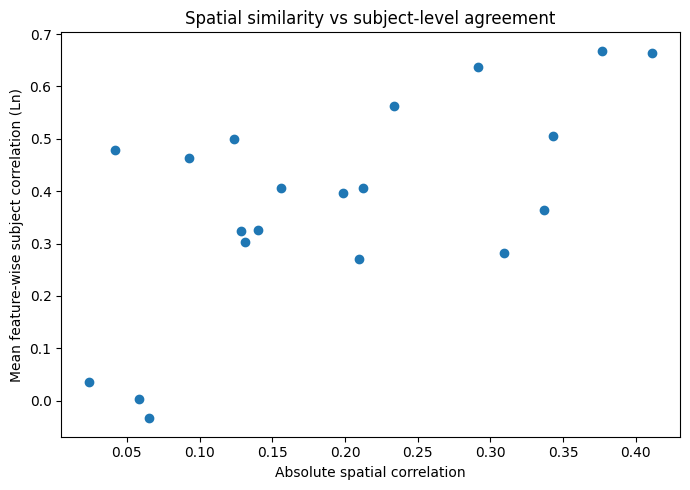

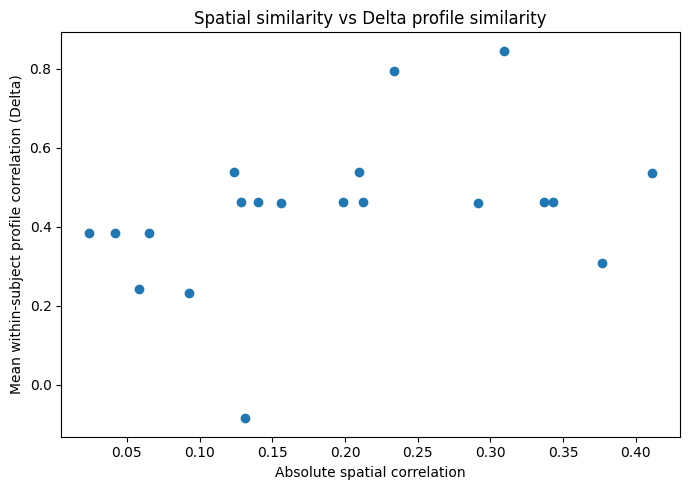

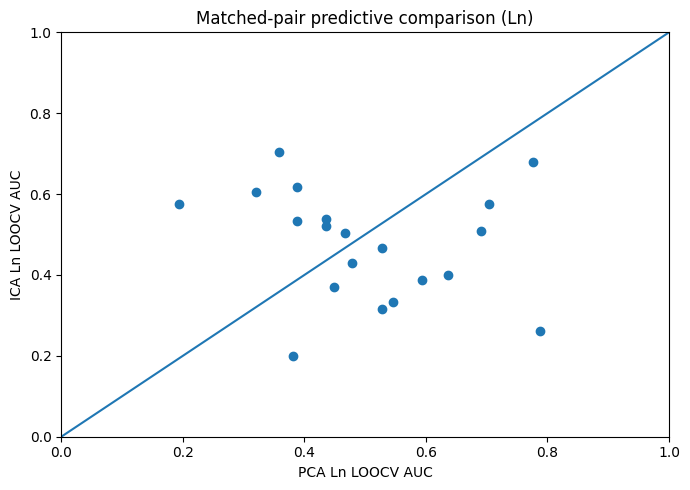

In [22]:

fig = plt.figure(figsize=(7, 5))
plt.scatter(interpret_df["abs_spatial_r"], interpret_df["mean_feature_subject_corr_Ln"])
plt.xlabel("Absolute spatial correlation")
plt.ylabel("Mean feature-wise subject correlation (Ln)")
plt.title("Spatial similarity vs subject-level agreement")
plt.tight_layout()
plt.savefig(OUTDIR / "scatter_abs_spatial_vs_subject_corr_ln.png", dpi=200, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(7, 5))
plt.scatter(interpret_df["abs_spatial_r"], interpret_df["DELTA_profile_corr_mean"])
plt.xlabel("Absolute spatial correlation")
plt.ylabel("Mean within-subject profile correlation (Delta)")
plt.title("Spatial similarity vs Delta profile similarity")
plt.tight_layout()
plt.savefig(OUTDIR / "scatter_abs_spatial_vs_delta_profile_corr.png", dpi=200, bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(7, 5))
plt.scatter(interpret_df["PCA_Ln_AUC"], interpret_df["ICA_Ln_AUC"])
plt.xlabel("PCA Ln LOOCV AUC")
plt.ylabel("ICA Ln LOOCV AUC")
plt.title("Matched-pair predictive comparison (Ln)")
lims = [0.0, 1.0]
plt.plot(lims, lims)
plt.xlim(lims)
plt.ylim(lims)
plt.tight_layout()
plt.savefig(OUTDIR / "scatter_pca_vs_ica_ln_auc.png", dpi=200, bbox_inches="tight")
plt.show()

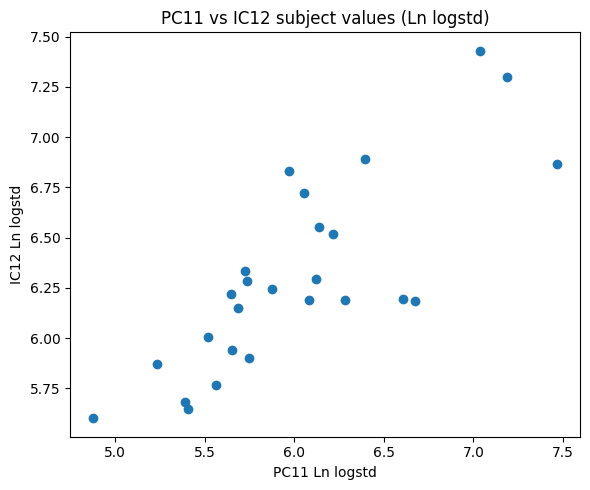

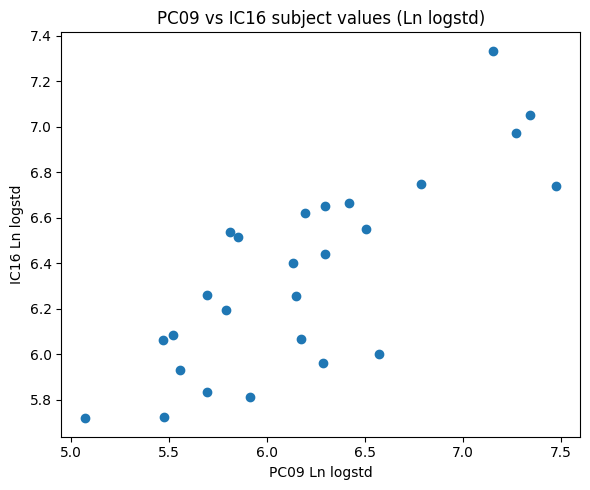

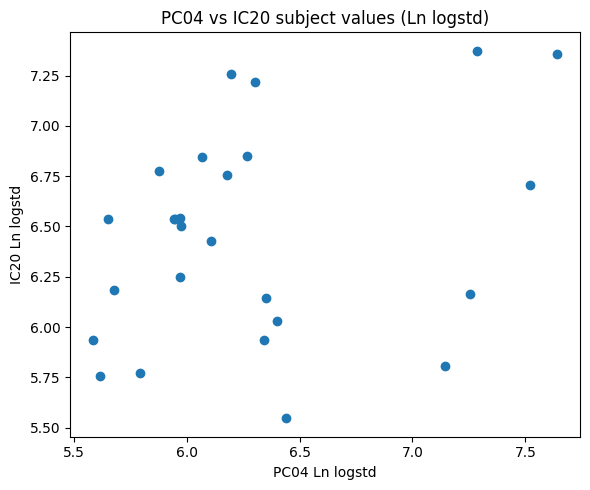

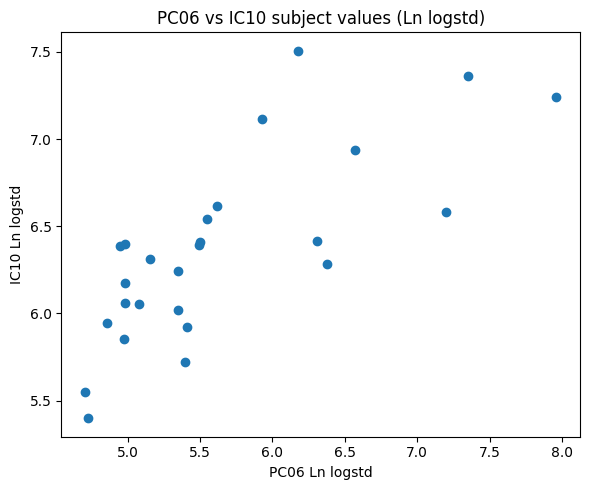

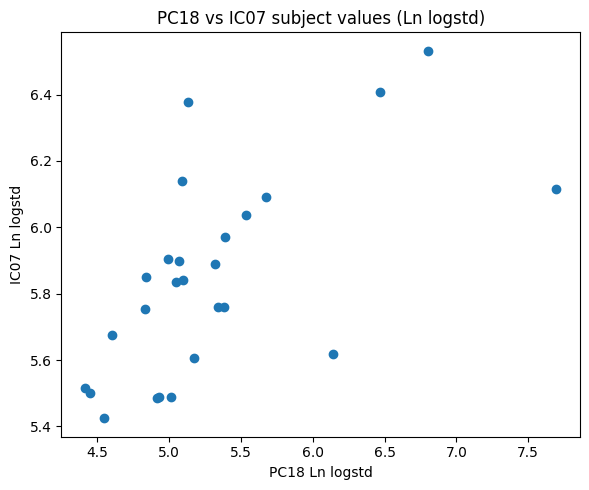

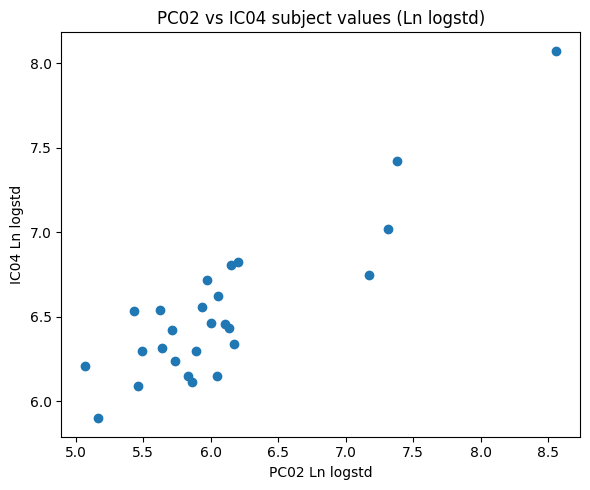

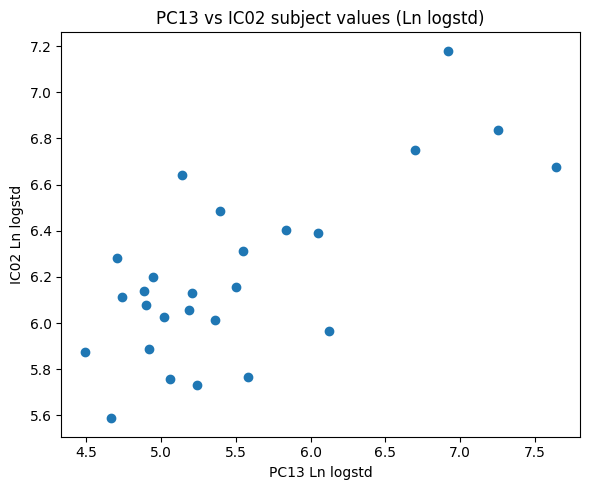

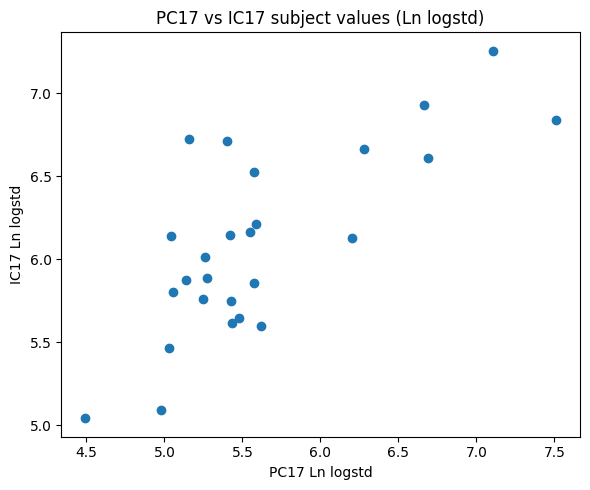

In [23]:

# Plot top matched pairs by subject-level agreement
top_pairs = interpret_df.head(TOP_N_MATCHES_TO_PLOT)[["pca_component", "ica_component"]].copy()

for _, r in top_pairs.iterrows():
    pc, ic = r["pca_component"], r["ica_component"]
    g = subject_tbl[(subject_tbl["pca_component"] == pc) & (subject_tbl["ica_component"] == ic)].copy()

    fig = plt.figure(figsize=(6, 5))
    plt.scatter(g["PCA_Ln_logstd"], g["ICA_Ln_logstd"])
    plt.xlabel(f"{pc} Ln logstd")
    plt.ylabel(f"{ic} Ln logstd")
    plt.title(f"{pc} vs {ic} subject values (Ln logstd)")
    plt.tight_layout()
    plt.savefig(OUTDIR / f"pair_{pc}_{ic}_Ln_logstd_scatter.png", dpi=200, bbox_inches="tight")
    plt.show()

## Step 8 — Quick interpretation helper
This cell labels each matched pair into easy-to-read categories.

In [24]:

def categorize_pair(row: pd.Series) -> str:
    spatial = row.get("abs_spatial_r", np.nan)
    subj = row.get("overall_subject_agreement_score", np.nan)
    gap = row.get("Ln_AUC_gap_PCA_minus_ICA", np.nan)

    if np.isfinite(spatial) and np.isfinite(subj):
        if spatial >= 0.30 and subj >= 0.20:
            base = "Good spatial + good subject agreement"
        elif spatial < 0.20 and subj >= 0.20:
            base = "Low spatial overlap but similar subject signal"
        elif spatial >= 0.30 and subj < 0.10:
            base = "Spatially similar but weak subject agreement"
        else:
            base = "Weak-to-moderate agreement"
    else:
        base = "Unclear"

    if np.isfinite(gap):
        if gap > 0.08:
            base += " | PCA stronger in Ln"
        elif gap < -0.08:
            base += " | ICA stronger in Ln"
        else:
            base += " | similar predictive strength"
    return base

interpret_labeled = interpret_df.copy()
interpret_labeled["interpretation_label"] = interpret_labeled.apply(categorize_pair, axis=1)
interpret_labeled.to_csv(OUTDIR / "matched_component_subject_level_interpretation_labeled.csv", index=False)

display_top(interpret_labeled[[
    "pca_component", "ica_component", "abs_spatial_r", "overall_subject_agreement_score",
    "PCA_Ln_AUC", "ICA_Ln_AUC", "Ln_AUC_gap_PCA_minus_ICA", "interpretation_label"
]], 15)

,pca_component,ica_component,abs_spatial_r,overall_subject_agreement_score,PCA_Ln_AUC,ICA_Ln_AUC,Ln_AUC_gap_PCA_minus_ICA,interpretation_label
0,PC11,IC12,0.233876,0.775787,0.775758,0.678788,0.096970,Weak-to-moderate agreement | PCA stronger in Ln
1,PC09,IC16,0.291118,0.697229,0.703030,0.575758,0.127273,Weak-to-moderate agreement | PCA stronger in Ln
2,PC04,IC20,0.309092,0.648894,0.436364,0.521212,-0.084848,Good spatial + good subject agreement | ICA st...
3,PC06,IC10,0.342757,0.639781,0.436364,0.539394,-0.103030,Good spatial + good subject agreement | ICA st...
4,PC18,IC07,0.042082,0.618070,0.448485,0.369697,0.078788,Low spatial overlap but similar subject signal...
5,PC02,IC04,0.410960,0.610096,0.466667,0.503030,-0.036364,Good spatial + good subject agreement | simila...
6,PC13,IC02,0.128419,0.592237,0.193939,0.575758,-0.381818,Low spatial overlap but similar subject signal...
7,PC17,IC17,0.198758,0.557244,0.478788,0.430303,0.048485,Low spatial overlap but similar subject signal...
8,PC14,IC11,0.123842,0.542647,0.545455,0.333333,0.212121,Low spatial overlap but similar subject signal...
9,PC10,IC01,0.212131,0.534180,0.690909,0.509091,0.181818,Weak-to-moderate agreement | PCA stronger in Ln


## Step 9 — Suggested reading of the results

Use the interpretation table like this:

- **High subject agreement + low spatial correlation**  
  PCA and ICA may be encoding the **same individual-difference signal** in different spatial forms.

- **High spatial correlation + high subject agreement**  
  Strong evidence that PCA and ICA are capturing a similar latent signal.

- **Low subject agreement + one method has higher AUC**  
  That method may be preserving a more predictive subject-level representation.

- **High Delta agreement**  
  Strong support that PCA and ICA reflect similar **L2-vs-L1 change patterns** across subjects.

### Especially important columns
- `abs_spatial_r`
- `mean_feature_subject_corr_Ln`
- `DELTA_profile_corr_mean`
- `DELTA_effect_profile_corr`
- `PCA_Ln_AUC`
- `ICA_Ln_AUC`
- `Ln_AUC_gap_PCA_minus_ICA`

## Final output files
This notebook saves:
- `subject_level_matched_component_table.csv`
- `featurewise_subject_correlations.csv`
- `subject_profile_similarity.csv`
- `pairwise_profile_similarity_summary.csv`
- `matched_pair_effect_sizes.csv`
- `matched_pair_effect_profile_agreement.csv`
- `matched_pair_loocv_auc.csv`
- `matched_component_subject_level_interpretation_table.csv`
- labeled plots and scatterplots